# Exploring the IBC 2026 Results

This notebook reproduces the video coding experiments presented in the IBC 2026 paper 🌐 *Scalable SSIM Estimation from PSNR for Per-Title and Context-Adaptive Encoding Workflows*.

The experiments use the Objective-1-fast dataset and three open-source video encoders: x264, x265, and SVT-AV1. Each sequence is encoded across a range of QP values, and ApproxSSIMate is used to estimate sequence-level SSIM from MSE and reference-derived statistics.

It walks through the main steps needed to reproduce the results, from downloading and encoding the test sequences to computing MSE, measured SSIM, and ApproxSSIMate estimates.

# Table of Contents

 - [1. Setup](#setup)
 - [2. Download test material](#download-test-material)
 - [3. Generate compressed video](#generate-compressed-videos)
 - [4. Compute reference data](#compute-reference-data)
 - [5. Compute the ApproxSSIMate reference constant](#compute-the-approxssimate-reference-constant)
 - [6. Estimate SSIM with ApproxSSIMate](#estimate-ssim-with-approxssimate)
 - [7. ApproxSSIMate error distribution](#approxssimate-error-distribution)
 - [8. Approximation error summary](#approximation-error-summary)



# Setup

In [1]:
# To install approxSSIMate, run the following command (just uncomment and run in this cell)

# %pip install -e ..

from approxssimate import compute_k, write_k_file, read_k_file, write_mse_file, read_mse_file, approx_ssim_from_k_mse

import av
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm


os.environ["SVT_LOG"] = "1"

from approxssimate import (
    approx_ssim_from_k_mse,
    compute_k,
)

ROOT = Path(".")
DATA_DIR = ROOT / "data"
SOURCE_DIR = Path.home() / "Datasets" / "objective-1-fast"
ENCODE_DIR = DATA_DIR / "encodes"
RESULTS_DIR = DATA_DIR / "results"
EXPECTED_FRAME_COUNT = 60

for path in (ENCODE_DIR, RESULTS_DIR):
    path.mkdir(parents=True, exist_ok=True)

## Encoder availability

The experiments use x264, x265, and SVT-AV1. Since encoder availability depends on the FFmpeg libraries included with the local PyAV installation, we first check which encoders are available.

The notebook will keep track of the available encoders and only run and display results for those encoders.

In [2]:
def encoder_available(name):
    try:
        av.codec.Codec(name, "w")
        return True
    except Exception:
        return False

GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

ENCODERS = {
    "x264": "libx264",
    "x265": "libx265",
    "SVT-AV1": "libsvtav1",
}

available_encoders = []

print(f"PyAV version: {av.__version__}")
print(f"libavcodec version: {av.library_versions['libavcodec']}")
print()

for name, codec_name in ENCODERS.items():
    try:
        codec = av.codec.Codec(codec_name, "w")
        available_encoders.append(name)
        print(f"{GREEN}[Found]{RESET}   {name:<8} {codec.long_name}")
    except Exception:
        print(f"{RED}[Missing]{RESET} {name:<8} {codec_name}")

print()
print("Available encoders:", ", ".join(available_encoders) or "none")

PyAV version: 18.1.0
libavcodec version: (62, 28, 102)

[Found]   x264     libx264 H.264 / AVC / MPEG-4 AVC / MPEG-4 part 10
[Found]   x265     libx265 H.265 / HEVC
[Found]   SVT-AV1  SVT-AV1(Scalable Video Technology for AV1) encoder

Available encoders: x264, x265, SVT-AV1


# Download test material

The experiments use the **Objective-1-fast** dataset, which contains 30 test sequences. The dataset is publicly available from [Xiph.org Video Test Media [derf's collection]](https://xiph.org/video/derf/):

https://media.xiph.org/video/derf/objective-1-fast.tar.gz

Download and extract the archive, then update `SOURCE_DIR` below to point to the extracted dataset directory.

In [3]:
if not SOURCE_DIR.exists():
    print(f"{RED}[Missing]{RESET} Dataset directory not found: {SOURCE_DIR}")
else:
    source_files = sorted(SOURCE_DIR.glob("*.y4m"))

    if len(source_files) == 30:
        print(f"{GREEN}[Found]{RESET}   Objective-1-fast dataset: 30 sequences")
    else:
        print(
            f"{RED}[Missing]{RESET} Objective-1-fast dataset: "
            f"expected 30 sequences, found {len(source_files)}"
        )

[Found]   Objective-1-fast dataset: 30 sequences


# Generate compressed videos

Each source sequence is encoded using the available x264, x265, and SVT-AV1 encoders.

Following the IBC experiments, x264 and x265 use QP values from **18 to 44** in steps of 2, while SVT-AV1 uses QP values from **24 to 63** in steps of 3. This gives 14 compressed versions of each source sequence for each encoder.

Encoded sequences are stored locally so that existing encodes can be reused when the notebook is run again.

> **Note:** This step performs several hundred video encodes and may take a few minutes to complete, depending on the available encoders and your system.

In [6]:
ENCODE_DIR.mkdir(parents=True, exist_ok=True)

QP_VALUES = {
    "x264": range(18, 45, 2),
    "x265": range(18, 45, 2),
    "SVT-AV1": range(24, 64, 3),
}

PRESETS = {
    "x264": "veryfast",
    "x265": "veryfast",
    "SVT-AV1": "10",
}

def has_expected_frame_count(path):
    try:
        with av.open(path) as container:
            stream = container.streams.video[0]
            frame_count = sum(1 for _ in container.decode(stream))

        return frame_count == EXPECTED_FRAME_COUNT

    except av.error.FFmpegError:
        return False

def load_video(path):
    with av.open(path) as container:
        stream = container.streams.video[0]

        frames = [
            frame
            for frame in container.decode(stream)
        ]

        metadata = {
            "rate": stream.average_rate,
            "width": stream.width,
            "height": stream.height,
            "pix_fmt": stream.codec_context.format.name,
        }

    return frames, metadata

def encode_video(source_frames, metadata, output_path, encoder, qp):
    codec_name = ENCODERS[encoder]

    with av.open(output_path, mode="w") as output_container:
        output_stream = output_container.add_stream(
            codec_name,
            rate=metadata["rate"],
        )

        output_stream.width = metadata["width"]
        output_stream.height = metadata["height"]
        output_stream.pix_fmt = metadata["pix_fmt"]

        options = {
            "qp": str(qp),
            "preset": PRESETS[encoder],
        }

        if encoder == "x265":
            options["x265-params"] = "log-level=error"

        output_stream.options = options

        for frame in source_frames:
            for packet in output_stream.encode(frame):
                output_container.mux(packet)

        for packet in output_stream.encode():
            output_container.mux(packet)

def encode_qp(source_frames, metadata, folder, source_path, encoder, qp):
    output_path = folder / f"{source_path.stem}_qp{qp}.mkv"

    if output_path.exists() and has_expected_frame_count(output_path):
        return

    encode_video(
        source_frames,
        metadata,
        output_path,
        encoder,
        qp,
    )

for source_path in tqdm(source_files, desc="Encoding sources"):
    source_frames, metadata = load_video(source_path)

    frame_count = len(source_frames)
    assert frame_count == EXPECTED_FRAME_COUNT, (
        f"{source_path} has {frame_count} frames, "
        f"expected {EXPECTED_FRAME_COUNT}"
    )

    for encoder in available_encoders:
        folder = ENCODE_DIR / encoder
        folder.mkdir(parents=True, exist_ok=True)

        Parallel(n_jobs=4, prefer="threads")(
            delayed(encode_qp)(
                source_frames,
                metadata,
                folder,
                source_path,
                encoder,
                qp,
            )
            for qp in QP_VALUES[encoder]
        )

Encoding sources: 100%|██████████| 30/30 [08:49<00:00, 17.64s/it]


## Compute reference quality metrics

For each compressed sequence, we decode the source and reconstructed videos frame by frame and compute luminance MSE and reference SSIM.

Following the IBC experiments, the frame-level measurements are averaged to obtain one MSE and SSIM value per sequence and QP.

> **Note:** This is the slowest step in the notebook. Computing SSIM over all sequences, QPs, and available codecs can take tens of minutes depending on your system.

In [7]:
def get_luma(frame):
    """Return the 8-bit luma plane of a PyAV video frame."""
    plane = frame.planes[0]

    return np.frombuffer(
        plane,
        dtype=np.uint8,
    ).reshape(
        frame.height,
        plane.line_size,
    )[:, :frame.width]

def load_luma_frames(path):
    frames = []

    with av.open(path) as container:
        stream = container.streams.video[0]

        for frame in container.decode(stream):
            frames.append(get_luma(frame).copy())

    return frames

def compute_metrics(source_frames, encoded_path):
    mse_values = []
    ssim_values = []

    with av.open(encoded_path) as container:
        stream = container.streams.video[0]

        for x, frame in zip(source_frames, container.decode(stream)):
            y = get_luma(frame)

            diff = x.astype(np.float32) - y
            mse_values.append(np.mean(diff * diff))
            ssim_values.append(ssim(x, y, data_range=255))

    return mse_values, np.mean(ssim_values)


RESULTS_FILE = RESULTS_DIR / "reference_metrics.csv"
MSE_DIR = RESULTS_DIR / "mse"

if RESULTS_FILE.exists():
    print(f"{GREEN}[Found]{RESET}   Loading cached reference metrics")
    results_df = pd.read_csv(RESULTS_FILE)

else:
    results = []

    for source_path in tqdm(source_files, desc="Computing metrics"):
        source_frames = load_luma_frames(source_path)
        frame_count = len(source_frames)

        assert frame_count == EXPECTED_FRAME_COUNT, (
            f"{source_path} has {frame_count} frames, "
            f"expected {EXPECTED_FRAME_COUNT}"
        )
        
        for encoder in available_encoders:
            folder = ENCODE_DIR / encoder
            mse_folder = MSE_DIR / encoder
            mse_folder.mkdir(parents=True, exist_ok=True)

            metrics = Parallel(n_jobs=4, prefer="threads")(
                delayed(compute_metrics)(
                    source_frames,
                    folder / f"{source_path.stem}_qp{qp}.mkv",
                )
                for qp in QP_VALUES[encoder]
            )

            for qp, (mse_values, measured_ssim) in zip(
                QP_VALUES[encoder],
                metrics,
            ):
                encoded_path = folder / f"{source_path.stem}_qp{qp}.mkv"
                mse_path = mse_folder / f"{source_path.stem}_qp{qp}.mse"

                mse_frame_count = len(mse_values)
                assert mse_frame_count == EXPECTED_FRAME_COUNT, (
                    f"{mse_path.name} has {mse_frame_count} frames, "
                    f"expected {EXPECTED_FRAME_COUNT}"
                )

                write_mse_file(
                    mse_path,
                    name=f"{source_path.stem}_{encoder}_qp{qp}",
                    reference_path=str(source_path),
                    distorted_path=str(encoded_path),
                    width=source_frames[0].shape[1],
                    height=source_frames[0].shape[0],
                    mse_values=mse_values,
                )

                results.append({
                    "encoder": encoder,
                    "sequence": source_path.stem,
                    "qp": qp,
                    "mse": np.mean(mse_values),
                    "ssim": measured_ssim,
                })

    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

    print(f"{GREEN}[Saved]{RESET}   {RESULTS_FILE}")

for encoder in available_encoders:
    mse_files = list((MSE_DIR / encoder).glob("*.mse"))
    expected = 30 * len(QP_VALUES[encoder])

    if len(mse_files) == expected:
        print(f"{GREEN}[Found]{RESET}   {encoder}: {expected} MSE files")
    else:
        print(
            f"{RED}[Missing]{RESET} {encoder}: "
            f"expected {expected}, found {len(mse_files)}"
        )

Computing metrics: 100%|██████████| 30/30 [21:13<00:00, 42.44s/it]

[Saved]   data/results/reference_metrics.csv
[Found]   x264: 420 MSE files
[Found]   x265: 420 MSE files
[Found]   SVT-AV1: 420 MSE files


## Compute the ApproxSSIMate reference constant

ApproxSSIMate analyzes each uncompressed source sequence once to compute the source-dependent constant $k_X$.

For each sequence, $k$ is computed independently for every source frame and then averaged across the sequence. This single value can then be reused for all encoders and QP values derived from that source.

In [8]:
K_DIR = RESULTS_DIR / "k"
K_DIR.mkdir(parents=True, exist_ok=True)

for source_path in tqdm(source_files, desc="Computing k"):
    k_path = K_DIR / f"{source_path.stem}.k"

    if k_path.exists():
        continue

    source_frames = load_luma_frames(source_path)

    k_values = [
        compute_k(frame)
        for frame in source_frames
    ]

    height, width = source_frames[0].shape

    k_frame_count = len(k_values)
    assert k_frame_count == EXPECTED_FRAME_COUNT, (
        f"{source_path} has {k_frame_count} frames, "
        f"expected {EXPECTED_FRAME_COUNT}"
    )

    write_k_file(
        k_path,
        source_path=str(source_path),
        width=width,
        height=height,
        k_values=k_values,
    )

k_files = sorted(K_DIR.glob("*.k"))

if len(k_files) == 30:
    print(f"{GREEN}[Found]{RESET}   30 reference k files")
else:
    print(
        f"{RED}[Missing]{RESET} Expected 30 reference k files, "
        f"found {len(k_files)}"
    )

Computing k: 100%|██████████| 30/30 [00:30<00:00,  1.02s/it]

[Found]   30 reference k files


## Estimate SSIM with ApproxSSIMate

ApproxSSIMate combines the source-derived $k$ values with the measured MSE values to estimate SSIM.

For each encoded sequence, the corresponding `.k` and `.mse` files are loaded, the frame-level ApproxSSIMate values are computed, and the sequence mean is added to the results table.

In [10]:
approx_values = []

for row in tqdm(
    results_df.itertuples(),
    total=len(results_df),
    desc="ApproxSSIMate",
):
    k_path = K_DIR / f"{row.sequence}.k"
    mse_path = MSE_DIR / row.encoder / f"{row.sequence}_qp{row.qp}.mse"

    k = np.asarray(read_k_file(k_path)["k"])
    mse = np.asarray(read_mse_file(mse_path)["mse"])

    approx_values.append(
        np.mean(approx_ssim_from_k_mse(k, mse))
    )

results_df["approx_ssim"] = approx_values
results_df.to_csv(RESULTS_FILE, index=False)

ApproxSSIMate: 100%|██████████| 1260/1260 [00:00<00:00, 5583.77it/s]


## Aggregate SSIM results

We first compare the measured SSIM values with the ApproxSSIMate estimates across the full QP range.

For each encoder and QP, the results are averaged across all 30 sequences in the Objective-1-fast dataset.

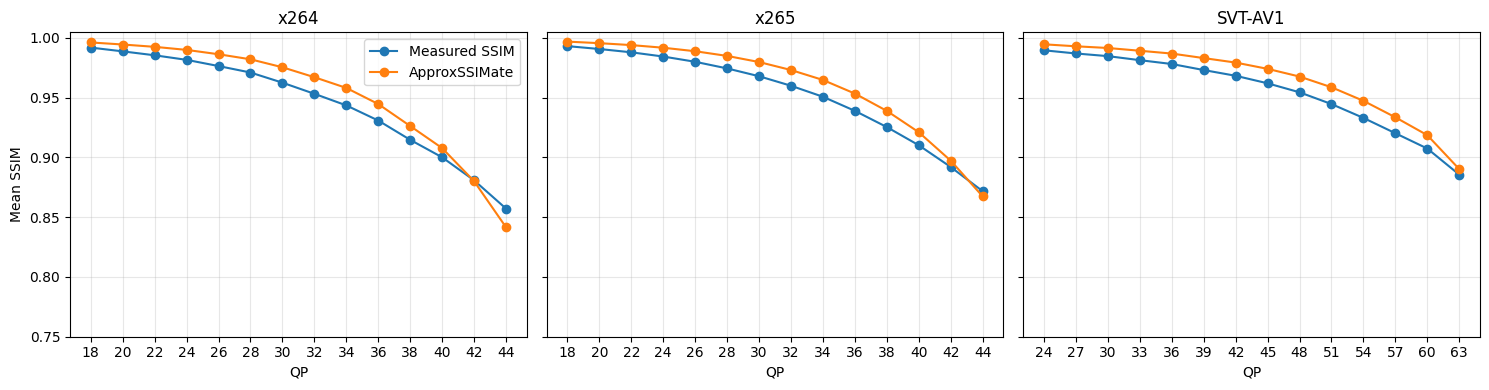

In [18]:
fig, axes = plt.subplots(
    1,
    len(available_encoders),
    figsize=(5 * len(available_encoders), 4),
    sharey=True,
)

if len(available_encoders) == 1:
    axes = [axes]

for ax, encoder in zip(axes, available_encoders):
    data = (
        results_df[results_df["encoder"] == encoder]
        .groupby("qp")[["ssim", "approx_ssim"]]
        .mean()
        .reset_index()
    )

    ax.plot(
        data["qp"],
        data["ssim"],
        marker="o",
        label="Measured SSIM",
    )

    ax.plot(
        data["qp"],
        data["approx_ssim"],
        marker="o",
        label="ApproxSSIMate",
    )

    ax.set_title(encoder)
    ax.set_xlabel("QP")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(data["qp"])
    ax.set_yticks(np.arange(0.75, 1.01, 0.05))

axes[0].set_ylabel("Mean SSIM")
axes[0].legend()

plt.tight_layout()
plt.show()

## ApproxSSIMate error distribution

To better understand the approximation error across individual sequences, we compute the difference between the ApproxSSIMate estimate and the measured SSIM for each sequence and QP.

The boxplots show how the error distribution evolves as compression becomes more aggressive.

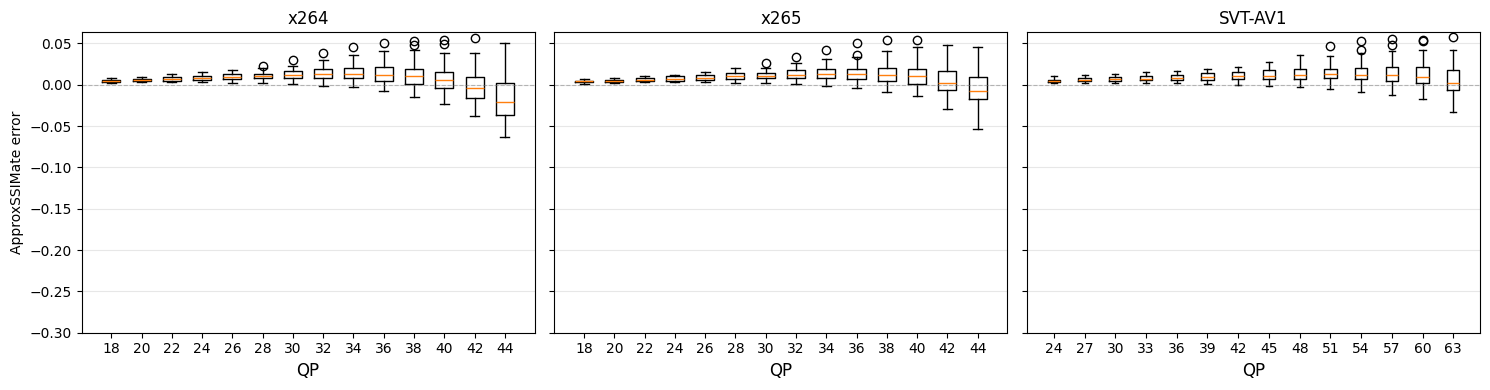

In [24]:
results_df["error"] = results_df["approx_ssim"] - results_df["ssim"]

fig, axes = plt.subplots(
    1,
    len(available_encoders),
    figsize=(5 * len(available_encoders), 4),
    sharey=True,
)

if len(available_encoders) == 1:
    axes = [axes]

for ax, encoder in zip(axes, available_encoders):
    data = results_df[
        results_df["encoder"] == encoder
    ]

    qps = list(QP_VALUES[encoder])

    box_data = [
        data[data["qp"] == qp]["error"].values
        for qp in qps
    ]

    ax.boxplot(
        box_data,
        positions=qps,
        widths=1.2,
    )

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_yticks(np.arange(0.05, -0.31, -0.05))
    ax.set_xlabel(f"{encoder} QP", fontsize=12)
    ax.grid(axis="y", alpha=0.3)

    ax.set_title(encoder)
    ax.set_xlabel("QP")
    ax.set_xticks(qps)

axes[0].set_ylabel("ApproxSSIMate error")

plt.tight_layout()
plt.show()

## Approximation error summary

The table below summarizes the ApproxSSIMate error for each encoder, where the error is defined as:

**ApproxSSIMate − measured SSIM**

- **Bias** shows whether the approximation tends to systematically overestimate or underestimate SSIM.
- **MAE** gives the average absolute approximation error.
- **RMSE** gives more weight to larger errors and is therefore more sensitive to outliers.
- **Max. absolute error** reports the largest error observed across all sequences and QP values.

Together, these statistics complement the boxplots by providing a compact numerical summary of the approximation accuracy for each encoder.

In [23]:
error_summary = (
    results_df
    .assign(error=lambda x: x["approx_ssim"] - x["ssim"])
    .groupby("encoder")["error"]
    .agg(
        bias="mean",
        mae=lambda x: np.mean(np.abs(x)),
        rmse=lambda x: np.sqrt(np.mean(x**2)),
        max_abs=lambda x: np.max(np.abs(x)),
    )
)

error_summary

,bias,mae,rmse,max_abs
encoder,,,,
SVT-AV1,0.009872,0.011437,0.014735,0.057336
x264,0.007460,0.013105,0.017376,0.063735
x265,0.008590,0.011416,0.014850,0.054376
